In [16]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"]="serif"
plt.rcParams["font.size"]=15


In [17]:
def perform_eda(df, filename="eda_summary.eps"):

    print("DATASET SHAPE")
    print(df.shape)

    print("FIRST 5 ROWS")
    print(df.head())

    print("LAST 5 ROWS")
    print(df.tail())

    print("DATASET INFORMATION")
    df.info()

    print("DATA TYPES")
    print(df.dtypes)

    print("STATISTICAL SUMMARY")
    print(df.describe(include='all'))

    print("DUPLICATE ROWS")
    print(df.duplicated().sum())

    num = df.select_dtypes(include=np.number)
    cat = df.select_dtypes(exclude=np.number)
    fig, axes = plt.subplots(6, 2, figsize=(40, 50))
    axes = axes.flatten()

    # 1 Missing Values
    miss = df.isnull().sum()
    axes[0].bar(miss.index, miss.values)
    axes[0].set_title("Missing Values", fontweight="bold")
    axes[0].tick_params(axis='x', rotation=90)

    # 2 Correlation Heatmap
    if len(num.columns) > 1:
        sns.heatmap(
            num.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            ax=axes[1]
        )
    axes[1].set_title("Correlation Heatmap", fontweight="bold")

    # 3 Histogram
    if len(num.columns):
        sns.histplot(num.iloc[:,0], kde=True, ax=axes[2])
    axes[2].set_title("Histogram", fontweight="bold")

    # 4 Boxplot
    if len(num.columns):
        sns.boxplot(y=num.iloc[:,0], ax=axes[3])
    axes[3].set_title("Boxplot", fontweight="bold")

    # 5 Scatter
    if len(num.columns) >= 2:
        sns.scatterplot(
            x=num.iloc[:,0],
            y=num.iloc[:,1],
            ax=axes[4]
        )
    axes[4].set_title("Scatter Plot", fontweight="bold")

    # 6 Countplot
    if len(cat.columns):
        top = cat.iloc[:,0].value_counts().head(10)
        sns.barplot(
            x=top.index,
            y=top.values,
            ax=axes[5]
        )
        axes[5].tick_params(axis='x', rotation=90)
    axes[5].set_title("Top Categories", fontweight="bold")

    # 7 Pie Chart
    if len(cat.columns):
        top = cat.iloc[:,0].value_counts().head(6)
        axes[6].pie(
            top.values,
            labels=top.index,
            autopct="%1.1f%%"
        )
    axes[6].set_title("Category Distribution", fontweight="bold")

    # 8 Mean Values
    if len(num.columns):
        num.mean().plot.bar(ax=axes[7])
        axes[7].tick_params(axis='x', rotation=90)
    axes[7].set_title("Feature Means", fontweight="bold")

    # 9 Violin
    if len(num.columns):
        sns.violinplot(y=num.iloc[:,0], ax=axes[8])
    axes[8].set_title("Violin Plot", fontweight="bold")

    # 10 Density
    if len(num.columns):
        sns.kdeplot(num.iloc[:,0], fill=True, ax=axes[9])
    axes[9].set_title("Density Plot", fontweight="bold")

    # 11 Outliers
    if len(num.columns):
        counts=[]
        for c in num.columns:
            Q1=num[c].quantile(.25)
            Q3=num[c].quantile(.75)
            IQR=Q3-Q1
            lower=Q1-1.5*IQR
            upper=Q3+1.5*IQR
            counts.append(((num[c]<lower)|(num[c]>upper)).sum())
        axes[10].bar(num.columns, counts)
        axes[10].tick_params(axis='x', rotation=90)
    axes[10].set_title("Outlier Count", fontweight="bold")

    # 12 Summary Table
    axes[11].axis("off")
    summary = [
        f"Rows : {df.shape[0]}",
        f"Columns : {df.shape[1]}",
        f"Missing : {df.isnull().sum().sum()}",
        f"Duplicates : {df.duplicated().sum()}",
        f"Numeric : {len(num.columns)}",
        f"Categorical : {len(cat.columns)}"
    ]
    axes[11].text(
        0.05,
        0.95,
        "\n".join(summary),
        fontsize=16,
        verticalalignment="top",
        bbox=dict(facecolor="whitesmoke", edgecolor="black")
    )
    axes[11].set_title("Dataset Summary", fontweight="bold")

    plt.tight_layout()
    plt.savefig(
        filename,
        dpi=600,
        format="eps",
        bbox_inches="tight"
    )
    plt.show()

In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

def preprocess_data(df,drop_columns=None,missing_num="mean",missing_cat="mode",encoding="label",scaling="standard",outliers="iqr"):

    print("DATA PREPROCESSING")

    df = df.copy()

    # 1. Drop unwanted columns
    if drop_columns:
        df.drop(columns=drop_columns, inplace=True, errors="ignore")
        print("\nDropped Columns:")
        print(drop_columns)

    # 2. Separate Numeric and Categorical Columns
    numeric_cols = df.select_dtypes(include=np.number).columns
    categorical_cols = df.select_dtypes(exclude=np.number).columns

    # 3. Handle Missing Numeric Values
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            if missing_num == "mean":
                df[col].fillna(df[col].mean(), inplace=True)
            elif missing_num == "median":
                df[col].fillna(df[col].median(), inplace=True)
            elif missing_num == "zero":
                df[col].fillna(0, inplace=True)

    # 4. Handle Missing Categorical Values
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            if missing_cat == "mode":
                df[col].fillna(df[col].mode()[0], inplace=True)
            else:
                df[col].fillna("Unknown", inplace=True)

    # 5. Handle Outliers
    if outliers == "iqr":
        for col in numeric_cols:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            df[col] = df[col].clip(lower, upper)
        print("\nOutliers Handled")

    # 6. Encode Categorical Variables
    if encoding == "label":
        le = LabelEncoder()
        for col in categorical_cols:
            df[col] = le.fit_transform(df[col].astype(str))
        print("\nLabel Encoding Applied")

    elif encoding == "onehot":
        df = pd.get_dummies(df,
                            columns=categorical_cols,
                            drop_first=True)
        print("\nOne Hot Encoding Applied")

    # 7. Feature Scaling
    numeric_cols = df.select_dtypes(include=np.number).columns

    if scaling == "standard":
        scaler = StandardScaler()
        df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
        print("\nStandard Scaling Applied")

    elif scaling == "minmax":
        scaler = MinMaxScaler()
        df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
        print("\nMin-Max Scaling Applied")

    return df

In [19]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, chi2, f_classif

def feature_selection(X, y, method="selectkbest", k=5):

    print("FEATURE SELECTION")
    if method == "selectkbest":
        selector = SelectKBest(score_func=f_classif, k=k)
    elif method == "anova":
        selector = SelectKBest(score_func=f_classif, k=k)
    elif method == "chi2":
        selector = SelectKBest(score_func=chi2, k=k)
    else:
        print("Invalid Method")
        return X

    X_new = selector.fit_transform(X, y)
    selected_features = X.columns[selector.get_support()]

    print("\nSelected Features:")
    print(selected_features.tolist())

    return pd.DataFrame(X_new, columns=selected_features)

In [20]:
from sklearn.model_selection import train_test_split

def split_data(X,
               y,
               test_size=0.2,
               validation_size=0.1,
               random_state=42):

    print("DATA SPLITTING")

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state
    )

    val_size = validation_size / (1 - test_size)

    X_train, X_val, y_train, y_val = train_test_split(
        X_train,
        y_train,
        test_size=val_size,
        random_state=random_state
    )

    print("Training Shape :", X_train.shape)
    print("Validation Shape :", X_val.shape)
    print("Testing Shape :", X_test.shape)

    return X_train, X_val, X_test, y_train, y_val, y_test

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(task,y_true=None,y_pred=None,X=None):

    print("MODEL EVALUATION")

    if task == "regression":
        print("MAE :", mean_absolute_error(y_true, y_pred))
        mse = mean_squared_error(y_true, y_pred)
        print("MSE :", mse)
        print("RMSE :", np.sqrt(mse))
        print("R2 Score :", r2_score(y_true, y_pred))

    elif task == "classification":
        print("Accuracy :", accuracy_score(y_true, y_pred))
        print("Precision :", precision_score(y_true, y_pred, average="weighted"))
        print("Recall :", recall_score(y_true, y_pred, average="weighted"))
        print("F1 Score :", f1_score(y_true, y_pred, average="weighted"))

        cm = confusion_matrix(y_true, y_pred)
        ConfusionMatrixDisplay(cm).plot()
        plt.show()

    else:

        print("Invalid Task")

EDA BEFORE PREPROCESSING
DATASET SHAPE
(103, 14)
FIRST 5 ROWS
         Brand                          Model  AccelSec  TopSpeed_KmH  \
0       Tesla   Model 3 Long Range Dual Motor       4.6           233   
1  Volkswagen                       ID.3 Pure      10.0           160   
2    Polestar                               2       4.7           210   
3         BMW                            iX3        6.8           180   
4       Honda                              e        9.5           145   

   Range_Km  Efficiency_WhKm FastCharge_KmH RapidCharge PowerTrain  \
0       450              161            940         Yes        AWD   
1       270              167            250         Yes        RWD   
2       400              181            620         Yes        AWD   
3       360              206            560         Yes        RWD   
4       170              168            190         Yes        RWD   

     PlugType  BodyStyle Segment  Seats  PriceEuro  
0  Type 2 CCS      Sedan 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


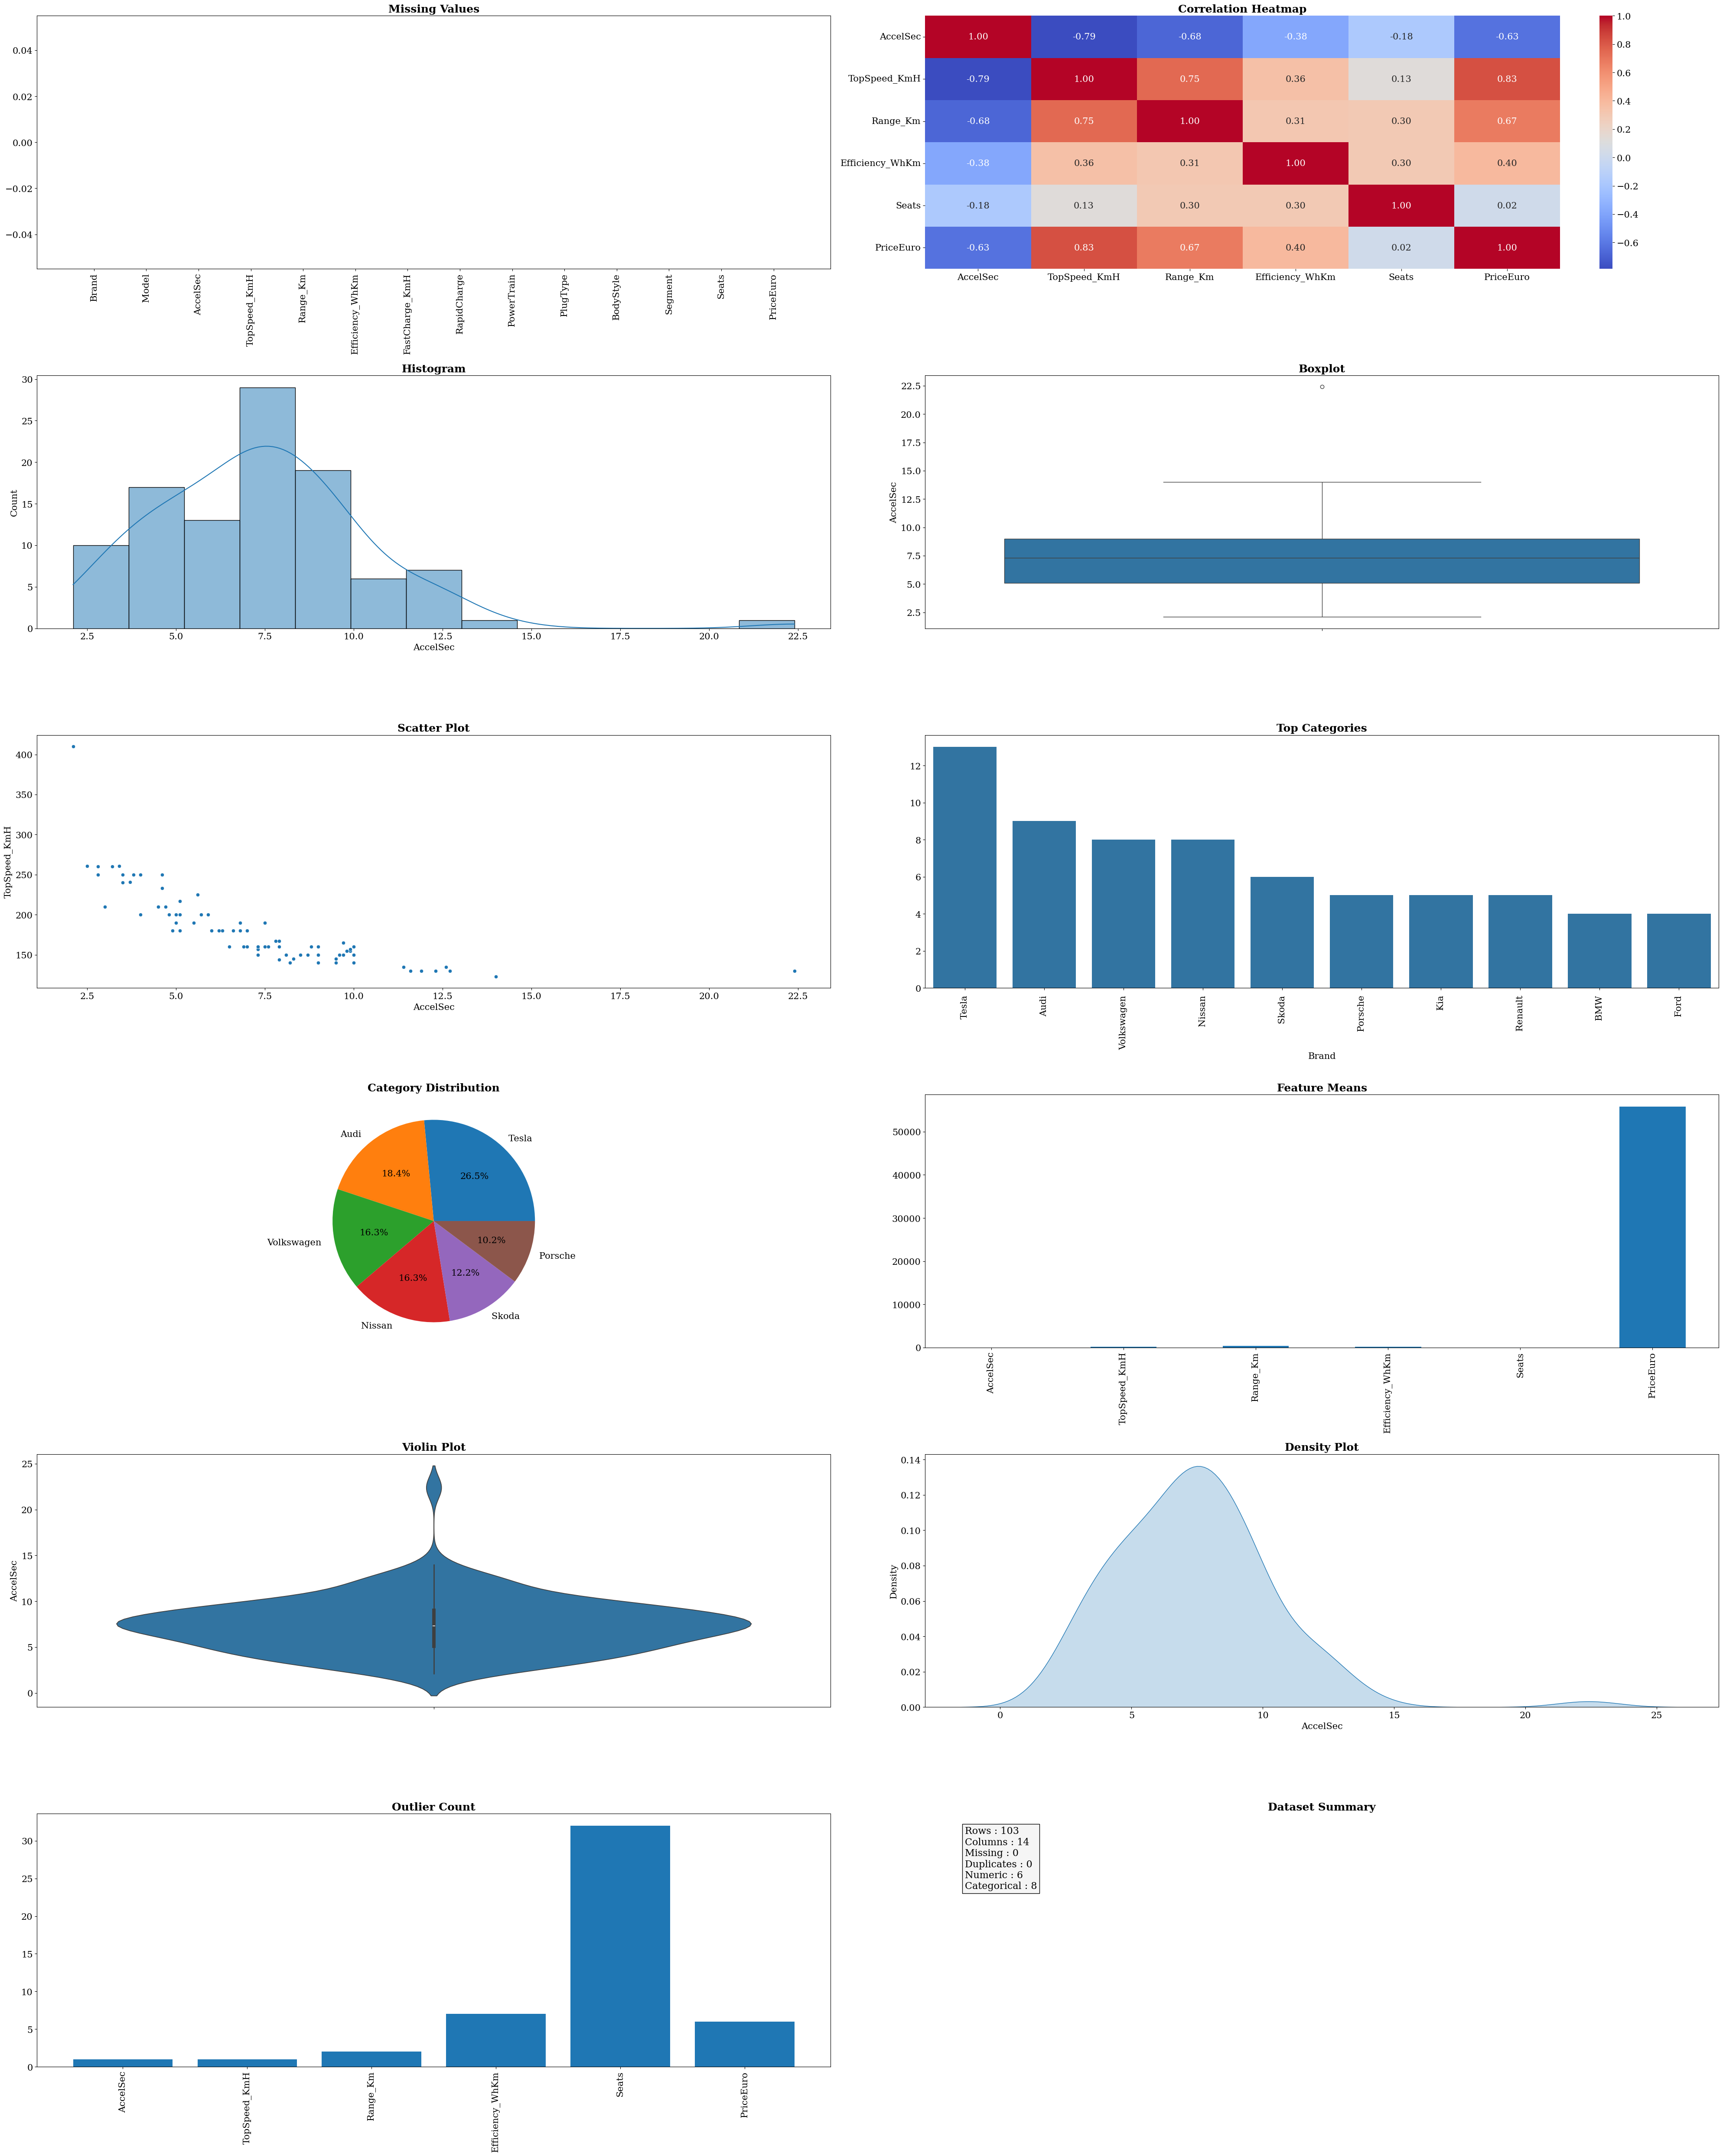

DATA PREPROCESSING

Outliers Handled

Label Encoding Applied

Standard Scaling Applied
EDA AFTER PREPROCESSING
DATASET SHAPE
(103, 14)
FIRST 5 ROWS
      Brand     Model  AccelSec  TopSpeed_KmH  Range_Km  Efficiency_WhKm  \
0  1.137815 -0.164717 -1.003306      1.447243  1.066475        -0.998117   
1  1.233096 -0.604947  0.986492     -0.469583 -0.591592        -0.782478   
2  0.470852 -1.722455 -0.966458      0.843312  0.605901        -0.279319   
3 -1.530038  1.697797 -0.192648      0.055575  0.237442         0.619178   
4 -0.863075  0.918928  0.802252     -0.863451 -1.512739        -0.746538   

   FastCharge_KmH  RapidCharge  PowerTrain  PlugType  BodyStyle   Segment  \
0        2.093613     0.225877   -1.075633  0.201008   1.167456  0.224027   
1       -0.968676     0.225877    1.471268  0.201008  -1.229514 -0.367634   
2        1.096589     0.225877   -1.075633  0.201008  -0.830019  0.224027   
3        0.811724     0.225877    1.471268  0.201008   0.767961  0.224027   
4       -1

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


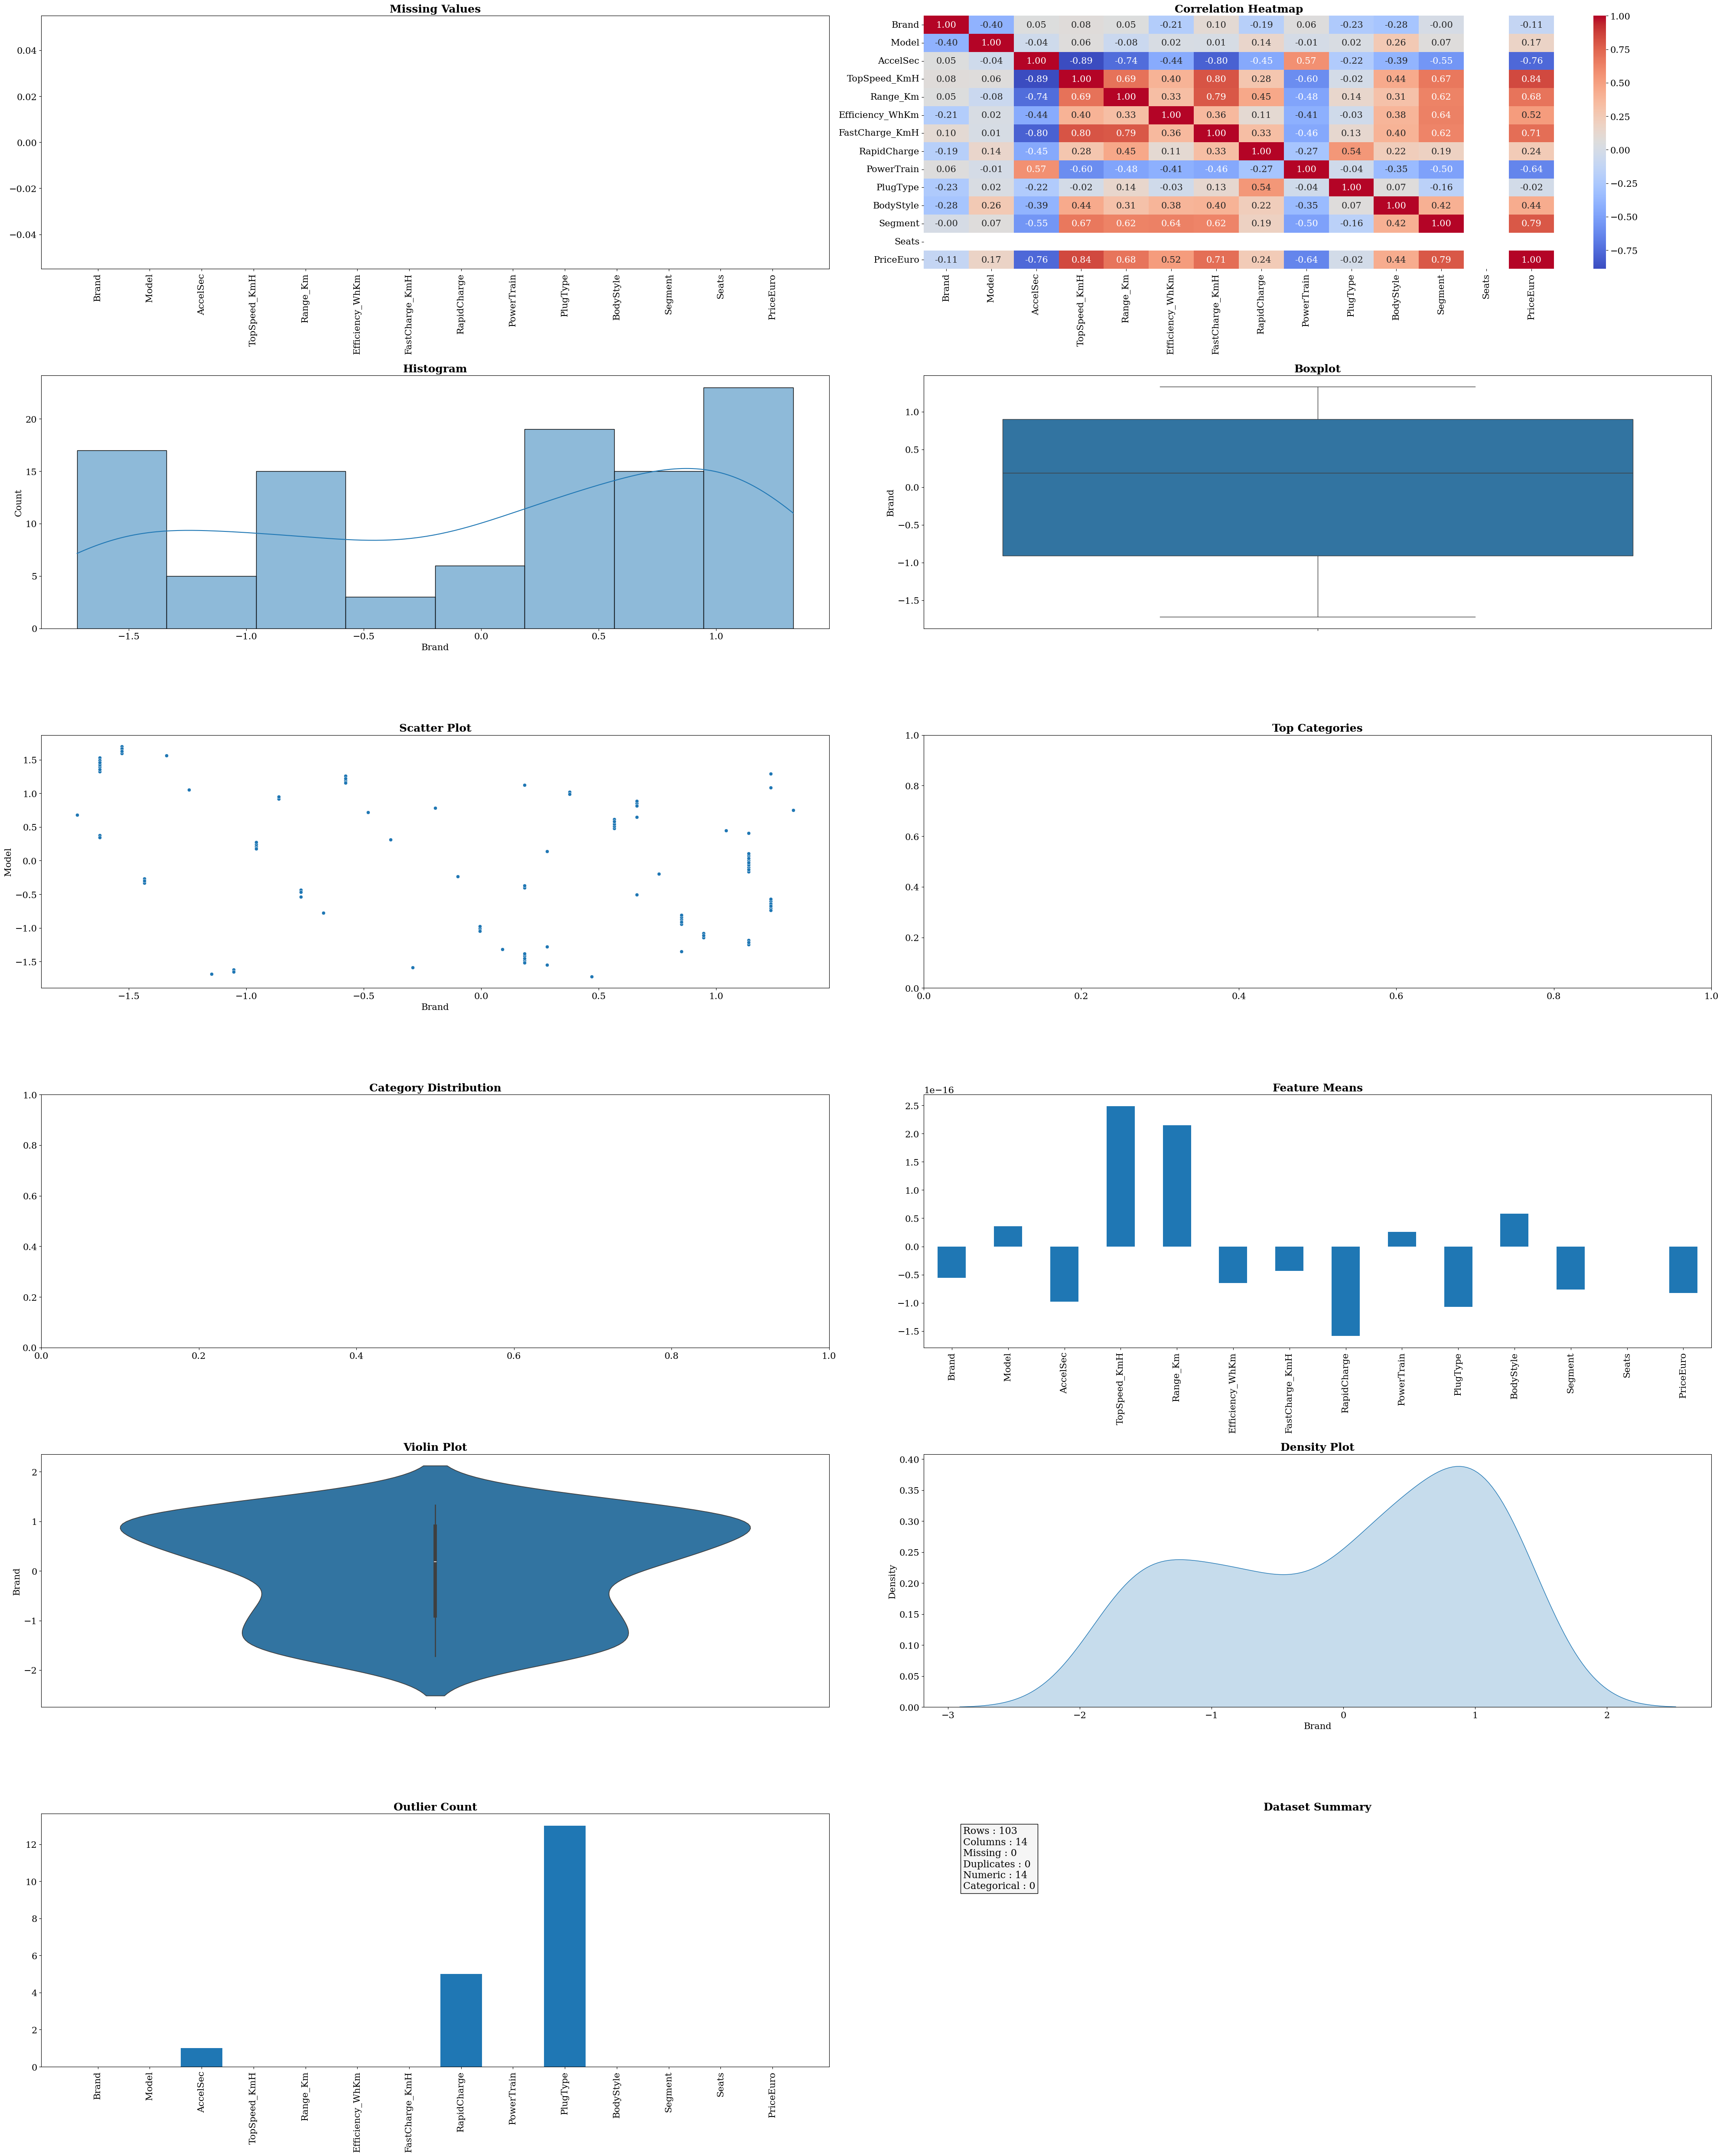

FEATURE SELECTION

Selected Features:
['AccelSec', 'FastCharge_KmH', 'RapidCharge', 'PlugType', 'Segment']
DATA SPLITTING
Training Shape : (71, 5)
Validation Shape : (11, 5)
Testing Shape : (21, 5)

REGRESSION MODEL
MODEL EVALUATION
MAE : 0.3788909542438544
MSE : 0.27482686024636516
RMSE : 0.5242393158151772
R2 Score : 0.6860123848598272


c:\Users\sayed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 7 12] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\sayed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
c:\Users\sayed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
from sklearn.linear_model import LogisticRegression, LinearRegression

def main():

    # Load Dataset
    df = pd.read_csv("ElectricCarData_Clean.csv")
    print("EDA BEFORE PREPROCESSING")
    perform_eda(df, "before_preprocessing.eps")

    # Data Preprocessing
    df = preprocess_data(df)
    print("EDA AFTER PREPROCESSING")
    perform_eda(df, "after_preprocessing.eps")

    # Select Target Column
    target = df.columns[-1]
    X = df.drop(columns=[target])
    y = df[target]

    # Feature Selection
    X = feature_selection(
        X,
        y,
        method="selectkbest",
        k=min(5, X.shape[1])
    )

    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

    if y.nunique() <= 10:

        print("\nCLASSIFICATION MODEL")

        model = LogisticRegression(max_iter=1000)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        evaluate_model(
            task="classification",
            y_true=y_test,
            y_pred=y_pred
        )

    else:

        print("\nREGRESSION MODEL")

        model = LinearRegression()

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        evaluate_model(
            task="regression",
            y_true=y_test,
            y_pred=y_pred
        )


if __name__ == "__main__":
    main()